# DOM Hourly Energy Consumption — RNN vs LSTM Forecasting

**Dataset:** DOM_hourly.csv  (~116k hourly records, 2005-12-31 → 2018-01-02)  
**Models:** Simple RNN and LSTM implemented in PyTorch (`models.py`)  
**Goal:** One-step-ahead forecasting; compare RNN vs LSTM on MSE, MAE, and R²

This notebook builds and compares two deep learning models — a **Simple RNN** and an **LSTM** — to forecast hourly electricity demand in the Dayton Power and Light (DOM) service area in Ohio.

### What we compare
We train **4 model configurations** and compare them head-to-head:

| Config | Architecture | Input features |
|--------|-------------|----------------|
| RNN Baseline | 3-layer Simple RNN | DOM_MW only |
| RNN + Features | 3-layer Simple RNN | DOM_MW + 6 cyclical time embeddings |
| LSTM Baseline | 3-layer LSTM | DOM_MW only |
| LSTM + Features | 3-layer LSTM | DOM_MW + 6 cyclical time embeddings |


### References
- Kaggle data: https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption/data?select=DOM_hourly.csv
- PyTorch RNN docs: https://pytorch.org/docs/stable/generated/torch.nn.RNN.html
- PyTorch LSTM docs: https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html
- Sequence length discussion: https://stackoverflow.com/questions/49573242/what-is-sequence-length-in-lstm
- MinMaxScaler: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html
- R² score: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from models import RNNModel, LSTMModel

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


# Part I — Exploratory Data Analysis (EDA)

Before building any model, we need to understand the structure and behaviour of the data. EDA helps us get better sense of data patterns, distributions, outliers and feature correlation.

In [2]:
df = pd.read_csv("DOM_hourly.csv", index_col="Datetime", parse_dates=["Datetime"])
df = df.sort_index()

print("Shape", df.shape)
print("Date range:", df.index.min(), df.index.max())
print("Missing:", df.isna().sum().values[0])
df.describe()

Shape (116189, 1)
Date range: 2005-05-01 01:00:00 2018-08-03 00:00:00
Missing: 0


,DOM_MW
count,116189.000000
mean,10949.203625
std,2413.946569
min,1253.000000
25%,9322.000000
50%,10501.000000
75%,12378.000000
max,21651.000000


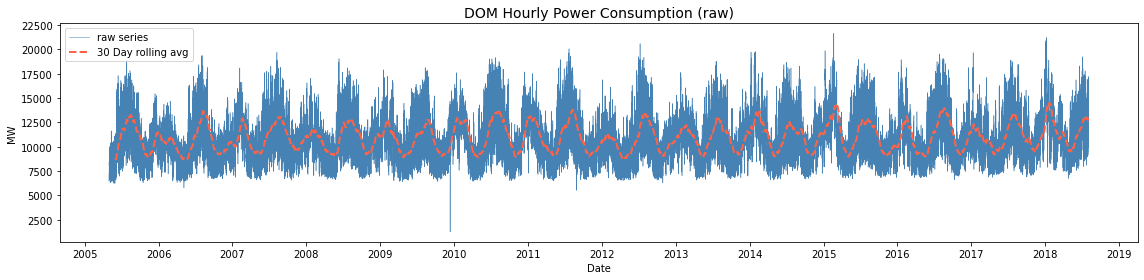

In [3]:
# demand peaks in winter and summer (heating and cooling loads) and dips in spring and autumn.

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df.index, df["DOM_MW"], linewidth=0.5, color="steelblue", label = 'raw series')
# rolling statistics
roll = df['DOM_MW'].rolling(24 * 30)   # 30-day window (720 hours)
ax.plot(df.index, roll.mean(), '--', color='tomato',
             linewidth=2, label='30 Day rolling avg', zorder=5)

ax.set_title("DOM Hourly Power Consumption (raw)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("MW")
ax.legend(loc = "upper left")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

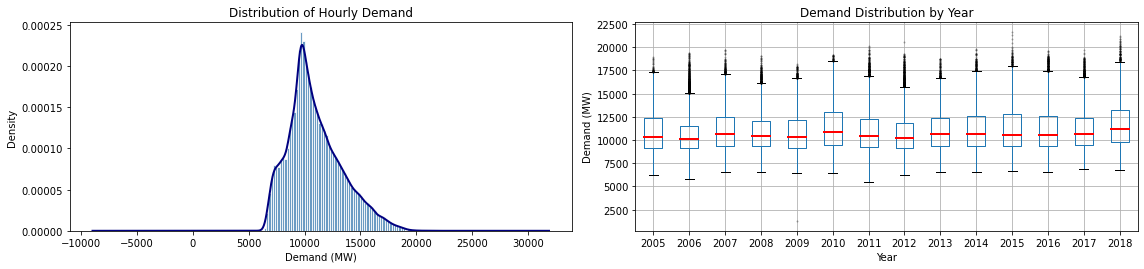

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Histogram: shape of the demand distribution
axes[0].hist(df['DOM_MW'], bins=100, color='steelblue', edgecolor='white',
             alpha=0.8, density=True)
df['DOM_MW'].plot.kde(ax=axes[0], color='navy', linewidth=2)
axes[0].set_title('Distribution of Hourly Demand', fontsize=12)
axes[0].set_xlabel('Demand (MW)')
axes[0].set_ylabel('Density')

# Box plot: reveal how distribution shifts over time
df_box = df.copy()
df_box['year'] = df_box.index.year
df_box.boxplot(column='DOM_MW', by='year', ax=axes[1],
               medianprops={'color': 'red', 'linewidth': 2},
               flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3})
axes[1].set_title('Demand Distribution by Year', fontsize=12)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Demand (MW)')
plt.sca(axes[1])
plt.xticks()
plt.suptitle('')

plt.tight_layout()
plt.show()

No handles with labels found to put in legend.


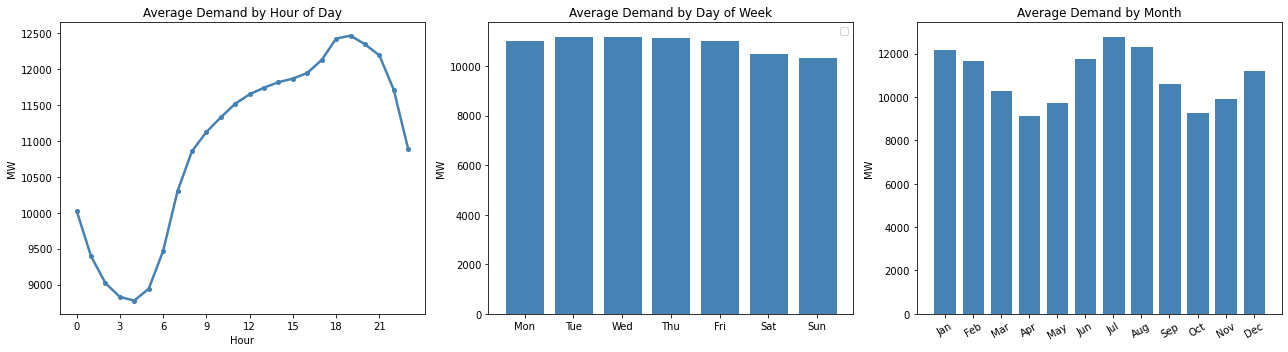

In [5]:
# seasonal patterns
df_feat = df.copy()
df_feat['hour']  = df_feat.index.hour
df_feat['dow']   = df_feat.index.dayofweek 
df_feat['month'] = df_feat.index.month

day_labels   = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Hourly profile: average demand by hour of day, morning ramp-up and evening peak
hourly = df_feat.groupby('hour')['DOM_MW'].agg(['mean', 'std'])
axes[0].plot(hourly.index, hourly['mean'], color='steelblue',
             linewidth=2.5, marker='o', markersize=4)
axes[0].set_title('Average Demand by Hour of Day', fontsize=12)
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('MW')
axes[0].set_xticks(range(0, 24, 3))

# Day-of-week: weekends lower demand than weekdays
dow_means  = df_feat.groupby('dow')['DOM_MW'].mean()
axes[1].bar(day_labels, dow_means.values, color='steelblue', edgecolor='white')
axes[1].set_title('Average Demand by Day of Week', fontsize=12)
axes[1].set_ylabel('MW')
axes[1].legend()

# Monthly profile: peaks in winter and summer, dips in spring and autumn
monthly_means = df_feat.groupby('month')['DOM_MW'].mean()
axes[2].bar(month_labels, monthly_means.values, color='steelblue', edgecolor='white')
axes[2].set_title('Average Demand by Month', fontsize=12)
axes[2].set_ylabel('MW')
plt.sca(axes[2])
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# Part II — Data Preprocessing

**Outlier detection** — remove extreme values

**Normalization and Split** — make sure all inputs are on a common scale [0, 1], and sepearte datasets to trian/valid/test to avoid data leakage


## Outlier detection

In [6]:
# IQR to detect outlier: [Q_1 - 1.5*IQR, Q_3 + 1.5 *IQR]
# clip outliers to the fence boundary

In [7]:
Q1  = df['DOM_MW'].quantile(0.25)
Q3  = df['DOM_MW'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers = df[(df['DOM_MW'] < lower_fence) | (df['DOM_MW'] > upper_fence)]

print(f"count outliers: {len(outliers):,} ({100*len(outliers)/len(df):.2f}% of data)")

count outliers: 2,106 (1.81% of data)


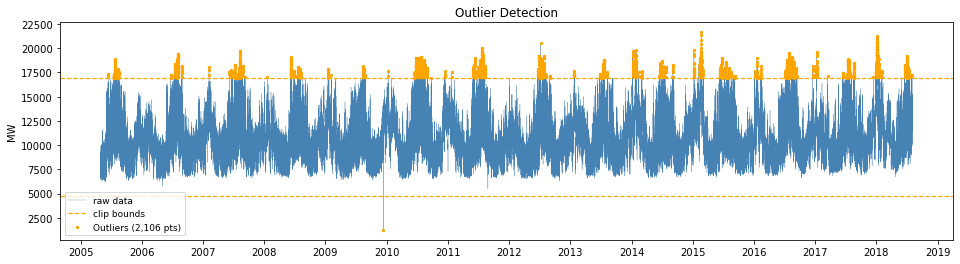

In [8]:
fig, ax = plt.subplots(figsize=(16, 4))

# Before treatment
ax.plot(df.index, df['DOM_MW'], linewidth=0.3, color='steelblue', label='raw data')
ax.scatter(outliers.index, outliers['DOM_MW'], color='orange', s=5,
                    zorder=5, label=f'Outliers ({len(outliers):,} pts)')
ax.axhline(lower_fence, color='orange', linestyle='--', linewidth=1.2, label='clip bounds')
ax.axhline(upper_fence, color='orange', linestyle='--', linewidth=1.2)
ax.set_title('Outlier Detection', fontsize=12)
ax.set_ylabel('MW')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())

## Normalization & Split

We use min-max scaler and split data based on time order.

| Split      | Proportion | Records | Time range | 
|------------|------------|--------|--------|
| Train      | 70%        | ~81k   |2005–2014|
| Validation | 15%        | ~17k   |2014–2016|
| Test       | 15%        | ~17k   |2016–2018|

In [9]:
df_clean = df.copy()
df_clean['DOM_MW'] = df_clean['DOM_MW'].clip(lower=lower_fence, upper=upper_fence)

In [10]:
raw_values = df_clean['DOM_MW'].values
n          = len(raw_values)
train_end  = int(n * 0.70)
valid_end  = int(n * 0.85)

train_raw = raw_values[:train_end].reshape(-1, 1)
valid_raw = raw_values[train_end:valid_end].reshape(-1, 1)
test_raw  = raw_values[valid_end:].reshape(-1, 1)

# Fit scaler on train only, then transform each split
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_raw)
train_scaled = scaler.transform(train_raw).flatten()
valid_scaled = scaler.transform(valid_raw).flatten()
test_scaled  = scaler.transform(test_raw).flatten()

train_idx = df_clean.index[:train_end]
valid_idx = df_clean.index[train_end:valid_end]
test_idx  = df_clean.index[valid_end:]

print(f'  Train : {len(train_scaled):>7,} samples, from {train_idx[0].date()} to {train_idx[-1].date()}')
print(f'  Valid : {len(valid_scaled):>7,} samples, from {valid_idx[0].date()} to {valid_idx[-1].date()}')
print(f'  Test  : {len(test_scaled):>7,} samples, from {test_idx[0].date()} to {test_idx[-1].date()}')


  Train :  81,332 samples, from 2005-05-01 to 2014-08-11
  Valid :  17,428 samples, from 2014-08-11 to 2016-08-06
  Test  :  17,429 samples, from 2016-08-06 to 2018-08-03


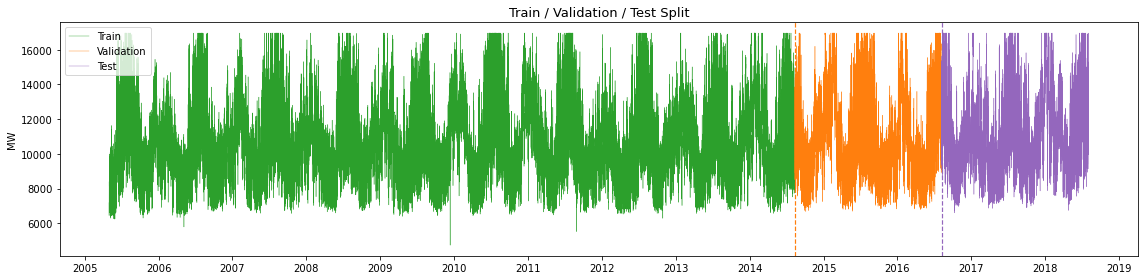

In [11]:
# ── Data Split Visualization ──────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(16, 4))

# Top panel: raw MW values, colored by split
for series_idx, col, label in [
    (slice(None, train_end),  "tab:green", 'Train'),
    (slice(train_end, valid_end),    "tab:orange", 'Validation'),
    (slice(valid_end, None),         "tab:purple",  'Test'),
]:
    idx = df_clean.index[series_idx]
    ax.plot(idx, df_clean['DOM_MW'].values[series_idx],
                 linewidth=0.4, color=col, label=label)

ax.axvline(train_idx[-1], color="tab:orange", linestyle='--', linewidth=1.2)
ax.axvline(valid_idx[-1], color="tab:purple", linestyle='--', linewidth=1.2)
ax.set_title('Train / Validation / Test Split', fontsize=13)
ax.set_ylabel('MW')
ax.legend(loc='upper left', fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.show()


# Part III — Feature Engineering

Use sin/cos encoding to project time into a circle to enrich features

In [12]:
def add_cyclical_features(index: pd.DatetimeIndex) -> np.ndarray:
    h = index.hour
    d = index.dayofweek
    m = index.month - 1

    return np.stack([
        np.sin(2 * np.pi * h / 24),
        np.cos(2 * np.pi * h / 24),
        np.sin(2 * np.pi * d / 7),
        np.cos(2 * np.pi * d / 7),
        np.sin(2 * np.pi * m / 12),
        np.cos(2 * np.pi * m / 12),
    ], axis=1).astype(np.float32)


train_time_feats = add_cyclical_features(train_idx)
valid_time_feats = add_cyclical_features(valid_idx)
test_time_feats  = add_cyclical_features(test_idx)

# Show a few example rows
sample_df = pd.DataFrame(train_time_feats[:2],
    columns=['sin_h','cos_h','sin_dow','cos_dow','sin_mon','cos_mon'])
sample_df.insert(0, 'datetime', train_idx[:2])
sample_df.insert(1, 'hour', train_idx[:2].hour)
print(sample_df.to_string(index=False))


           datetime  hour     sin_h     cos_h   sin_dow  cos_dow   sin_mon  cos_mon
2005-05-01 01:00:00     1  0.258819  0.965926 -0.781832  0.62349  0.866025     -0.5
2005-05-01 02:00:00     2  0.500000  0.866025 -0.781832  0.62349  0.866025     -0.5


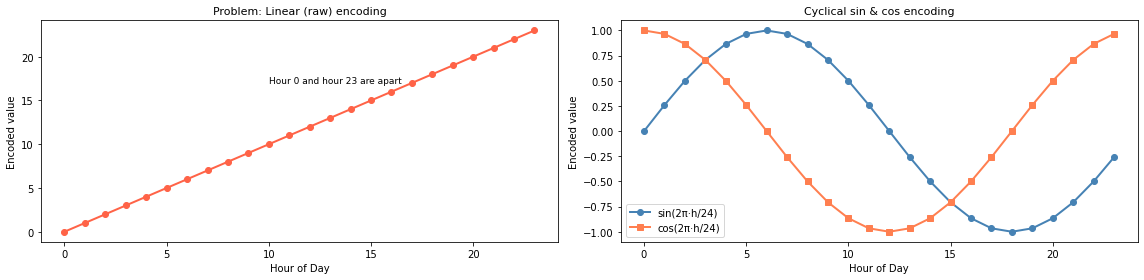

In [13]:
# Visualize: show why cyclical encoding works better than raw integers
hours  = np.arange(24)
sin_h  = np.sin(2 * np.pi * hours / 24)
cos_h  = np.cos(2 * np.pi * hours / 24)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Problem: raw encoding
axes[0].plot(hours, hours, 'o-', color='tomato', linewidth=2)
axes[0].annotate('Hour 0 and hour 23 are apart',
                 xy=(23, 23), xytext=(10, 17), fontsize=9)
axes[0].set_title('Problem: Linear (raw) encoding', fontsize=11)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Encoded value')

# Solution: sin + cos
axes[1].plot(hours, sin_h, 'o-', color='steelblue', label='sin(2π·h/24)', linewidth=2)
axes[1].plot(hours, cos_h, 's-', color='coral',     label='cos(2π·h/24)', linewidth=2)
axes[1].set_title('Cyclical sin & cos encoding', fontsize=11)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Encoded value')
axes[1].legend()

plt.tight_layout()
plt.show()


# Part IV — Dataset & Model Setup

## Create Sliding Window

we step through the time series and extract overlapping windows of length 24 (the sequence), each paired with the value immediately following it (the target).

Index: 

0   1   2  ...  23 | 24   ← window of 24 → predict index 24

1   2   3  ...  24 | 25   ← shift by 1 →  predict index 25


We build **two dataset classes**:
- TimeSeriesDataset: baseline with 1 feature (DOM_MW only)
- TimeSeriesDatasetWithFeatures: enhanced with 7 features (DOM_MW + 6 cyclical)



In [14]:
class TimeSeriesDataset(Dataset):
    """
    Baseline univariate dataset.
    Input X : (N, seq_len, 1)  — scaled DOM_MW values only
    Target y : (N, 1)          — next hour's scaled DOM_MW
    """
    def __init__(self, series: np.ndarray, seq_len: int):
        X_list, y_list = [], []
        for i in range(seq_len, len(series)):
            X_list.append(series[i - seq_len : i])
            y_list.append(series[i])
        self.X = torch.tensor(np.array(X_list), dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(np.array(y_list), dtype=torch.float32).unsqueeze(-1)

    def __len__(self):          return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]


class TimeSeriesDatasetWithFeatures(Dataset):
    """
    Enhanced multivariate dataset.
    Each time step: [scaled_DOM_MW, sin_h, cos_h, sin_dow, cos_dow, sin_mon, cos_mon]
    Input X : (N, seq_len, 7)
    Target y : (N, 1)          — next hour's scaled DOM_MW (feature index 0)
    """
    def __init__(self, series: np.ndarray, time_feats: np.ndarray, seq_len: int):
        combined = np.concatenate(
            [series.reshape(-1, 1), time_feats], axis=1
        ).astype(np.float32)   # (N_total, 7)

        X_list, y_list = [], []
        for i in range(seq_len, len(combined)):
            X_list.append(combined[i - seq_len : i, :])   # all 7 features
            y_list.append(combined[i, 0])                  # predict DOM_MW only
        self.X = torch.tensor(np.array(X_list), dtype=torch.float32)
        self.y = torch.tensor(np.array(y_list), dtype=torch.float32).unsqueeze(-1)

    def __len__(self):          return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

In [15]:
SEQ_LEN    = 24 
BATCH_SIZE = 512

# Build datasets
train_ds_base = TimeSeriesDataset(train_scaled, SEQ_LEN)
valid_ds_base = TimeSeriesDataset(valid_scaled, SEQ_LEN)
test_ds_base  = TimeSeriesDataset(test_scaled,  SEQ_LEN)

train_ds_feat = TimeSeriesDatasetWithFeatures(train_scaled, train_time_feats, SEQ_LEN)
valid_ds_feat = TimeSeriesDatasetWithFeatures(valid_scaled, valid_time_feats, SEQ_LEN)
test_ds_feat  = TimeSeriesDatasetWithFeatures(test_scaled,  test_time_feats,  SEQ_LEN)

def make_loaders(tr, va, te, bs=BATCH_SIZE):
    return (DataLoader(tr, batch_size=bs, shuffle=True,  drop_last=False),
            DataLoader(va, batch_size=bs, shuffle=False, drop_last=False),
            DataLoader(te, batch_size=bs, shuffle=False, drop_last=False))

train_loader_base, valid_loader_base, test_loader_base = make_loaders(train_ds_base, valid_ds_base, test_ds_base)
train_loader_feat, valid_loader_feat, test_loader_feat = make_loaders(train_ds_feat, valid_ds_feat, test_ds_feat)

print(f'Sequence length : {SEQ_LEN} hours')
print(f'Baseline  — X: {train_ds_base.X.shape},  y: {train_ds_base.y.shape}')
print(f'Enhanced  — X: {train_ds_feat.X.shape},  y: {train_ds_feat.y.shape}')


Sequence length : 24 hours
Baseline  — X: torch.Size([81308, 24, 1]),  y: torch.Size([81308, 1])
Enhanced  — X: torch.Size([81308, 24, 7]),  y: torch.Size([81308, 1])


## Training Utilities

In [16]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total = 0.0
    for Xb, yb in loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        # Gradient clipping: prevents exploding gradients in RNNs
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total += loss.item() * Xb.size(0)
    return total / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Compute average loss over a DataLoader without gradient tracking."""
    model.eval()
    total = 0.0
    for Xb, yb in loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        total += criterion(model(Xb), yb).item() * Xb.size(0)
    return total / len(loader.dataset)


@torch.no_grad()
def get_predictions(model, loader):
    """
    Run inference, then inverse-transform both predictions and targets
    back to the original MW scale for interpretable metric computation.
    """
    model.eval()
    preds, trues = [], []
    for Xb, yb in loader:
        preds.append(model(Xb.to(DEVICE)).cpu().numpy())
        trues.append(yb.numpy())
    y_pred_mw = scaler.inverse_transform(np.concatenate(preds).reshape(-1, 1)).flatten()
    y_true_mw = scaler.inverse_transform(np.concatenate(trues).reshape(-1, 1)).flatten()
    return y_true_mw, y_pred_mw


def compute_metrics(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'  {name:<30}  RMSE={rmse:>8.2f} MW  MAE={mae:>8.2f} MW  '
          f'R²={r2:.4f}  MAPE={mape:.2f}%')
    return {'model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}


def train_model(model, model_name, train_loader, valid_loader, epochs=15, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # Halve LR when validation loss stops improving for 2 consecutive epochs
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2, verbose=False)

    history    = {'train_loss': [], 'valid_loss': []}
    best_loss  = float('inf')
    best_state = None

    print(f'\n{"═"*62}')
    print(f'  Training: {model_name}')
    print(f'{"═"*62}')
    print(f'  {"Epoch":>5}  {"Train MSE":>12}  {"Valid MSE":>12}  Notes')
    print(f'  {"─"*50}')

    for epoch in range(1, epochs + 1):
        tl = train_one_epoch(model, train_loader, optimizer, criterion)
        vl = evaluate(model, valid_loader, criterion)
        scheduler.step(vl)
        history['train_loss'].append(tl)
        history['valid_loss'].append(vl)
        if vl < best_loss:
            best_loss  = vl
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            note = '✓ best checkpoint saved'
        else:
            note = ''
        print(f'  {epoch:>5}  {tl:>12.6f}  {vl:>12.6f}  {note}')

    # Restore the weights from the epoch with the lowest validation MSE
    model.load_state_dict(best_state)
    print(f'\n  Best validation MSE: {best_loss:.6f}')
    print(f'  Best weights restored.')
    return history


# Part V — Model Training

We train 4 model configurations. The architecture for each is defined in `models.py`:

- **RNN**: 3-layer `nn.RNN` with tanh activation, dropout between layers, and a final linear projection to 1 output
- **LSTM**: same structure but uses `nn.LSTM` — the key difference is the LSTM is able to remember or forget information over long sequences, mitigating the vanishing gradient problem that plagues plain RNNs

**Hyperparameters (same for all 4 models):**
| Param | Value | Reason |
|-------|-------|--------|
| hidden_size | 64 | Balances capacity vs. training speed |
| num_layers | 3 | Depth allows hierarchical temporal features |
| dropout | 0.15 | Light regularization; inter-layer only |
| optimizer | Adam | Adaptive learning rates, fast convergence |
| lr| 1e-3 | Standard starting point for Adam |
| epochs| 30 | Sufficient for convergence on this dataset size |
| batch_size| 512 | Large enough for stable gradients, fits in RAM |


In [17]:
HIDDEN = 64
LAYERS = 3
DROP   = 0.15
EPOCHS = 30

rnn_base  = RNNModel( input_size=1, hidden_size=HIDDEN, num_layers=LAYERS, dropout=DROP).to(DEVICE)
lstm_base = LSTMModel(input_size=1, hidden_size=HIDDEN, num_layers=LAYERS, dropout=DROP).to(DEVICE)
rnn_feat  = RNNModel( input_size=7, hidden_size=HIDDEN, num_layers=LAYERS, dropout=DROP).to(DEVICE)
lstm_feat = LSTMModel(input_size=7, hidden_size=HIDDEN, num_layers=LAYERS, dropout=DROP).to(DEVICE)

for name, m in [('RNN  (baseline, input=1)',   rnn_base),
                ('LSTM (baseline, input=1)',   lstm_base),
                ('RNN  (+features, input=7)', rnn_feat),
                ('LSTM (+features, input=7)', lstm_feat)]:
    print(f'  {name}: {sum(p.numel() for p in m.parameters()):>8,} parameters')

# LSTM has ~4× more parameters than RNN because each LSTM cell has 4 weight matrices (input, forget, output, cell gates)


  RNN  (baseline, input=1):   20,993 parameters
  LSTM (baseline, input=1):   83,777 parameters
  RNN  (+features, input=7):   21,377 parameters
  LSTM (+features, input=7):   85,313 parameters


## Training

### 1. RNN Baseline

In [18]:
hist_rnn_base = train_model(rnn_base, 'RNN Baseline',
                   train_loader_base, valid_loader_base,
                   epochs=EPOCHS)


══════════════════════════════════════════════════════════════
  Training: RNN Baseline
══════════════════════════════════════════════════════════════
  Epoch     Train MSE     Valid MSE  Notes
  ──────────────────────────────────────────────────
      1      0.020077      0.002104  ✓ best checkpoint saved
      2      0.003789      0.001648  ✓ best checkpoint saved
      3      0.002589      0.000703  ✓ best checkpoint saved
      4      0.002045      0.000478  ✓ best checkpoint saved
      5      0.001760      0.000441  ✓ best checkpoint saved
      6      0.001663      0.000405  ✓ best checkpoint saved
      7      0.001526      0.000395  ✓ best checkpoint saved
      8      0.001458      0.000372  ✓ best checkpoint saved
      9      0.001367      0.000373  
     10      0.001326      0.000365  ✓ best checkpoint saved
     11      0.001263      0.000347  ✓ best checkpoint saved
     12      0.001208      0.000362  
     13      0.001139      0.000348  
     14      0.001102      0

### 2. LSTM Baseline

In [19]:
hist_lstm_base = train_model(lstm_base, 'LSTM Baseline',
                   train_loader_base, valid_loader_base,
                   epochs=EPOCHS)


══════════════════════════════════════════════════════════════
  Training: LSTM Baseline
══════════════════════════════════════════════════════════════
  Epoch     Train MSE     Valid MSE  Notes
  ──────────────────────────────────────────────────
      1      0.048764      0.016028  ✓ best checkpoint saved
      2      0.009012      0.003323  ✓ best checkpoint saved
      3      0.004842      0.001965  ✓ best checkpoint saved
      4      0.003638      0.001382  ✓ best checkpoint saved
      5      0.003111      0.001181  ✓ best checkpoint saved
      6      0.002722      0.000959  ✓ best checkpoint saved
      7      0.002543      0.001165  
      8      0.002302      0.000727  ✓ best checkpoint saved
      9      0.002121      0.000722  ✓ best checkpoint saved
     10      0.001965      0.000518  ✓ best checkpoint saved
     11      0.001876      0.000467  ✓ best checkpoint saved
     12      0.001747      0.000493  
     13      0.001680      0.000496  
     14      0.001593      

### 3. RNN with Cyclical Features

In [21]:
hist_rnn_feat = train_model(rnn_feat, 'RNN with Cyclical Features',
                   train_loader_feat, valid_loader_feat,
                   epochs=EPOCHS)


══════════════════════════════════════════════════════════════
  Training: RNN with Cyclical Features
══════════════════════════════════════════════════════════════
  Epoch     Train MSE     Valid MSE  Notes
  ──────────────────────────────────────────────────
      1      0.016212      0.002175  ✓ best checkpoint saved
      2      0.003835      0.001239  ✓ best checkpoint saved
      3      0.002573      0.000886  ✓ best checkpoint saved
      4      0.002001      0.000714  ✓ best checkpoint saved
      5      0.001708      0.000589  ✓ best checkpoint saved
      6      0.001487      0.000518  ✓ best checkpoint saved
      7      0.001382      0.000409  ✓ best checkpoint saved
      8      0.001191      0.000380  ✓ best checkpoint saved
      9      0.001102      0.000370  ✓ best checkpoint saved
     10      0.001055      0.000334  ✓ best checkpoint saved
     11      0.000975      0.000358  
     12      0.000927      0.000340  
     13      0.000881      0.000337  
     14      0

### 4. LSTM with Cyclical Features

In [22]:
hist_lstm_feat = train_model(lstm_feat, 'LSTM with Cyclical Features',
                   train_loader_feat, valid_loader_feat,
                   epochs=EPOCHS)


══════════════════════════════════════════════════════════════
  Training: LSTM with Cyclical Features
══════════════════════════════════════════════════════════════
  Epoch     Train MSE     Valid MSE  Notes
  ──────────────────────────────────────────────────
      1      0.021463      0.004751  ✓ best checkpoint saved
      2      0.004452      0.002720  ✓ best checkpoint saved
      3      0.003153      0.001927  ✓ best checkpoint saved
      4      0.002618      0.001583  ✓ best checkpoint saved
      5      0.002238      0.001211  ✓ best checkpoint saved
      6      0.001989      0.001125  ✓ best checkpoint saved
      7      0.001792      0.001001  ✓ best checkpoint saved
      8      0.001616      0.000847  ✓ best checkpoint saved
      9      0.001506      0.000771  ✓ best checkpoint saved
     10      0.001402      0.000715  ✓ best checkpoint saved
     11      0.001310      0.000616  ✓ best checkpoint saved
     12      0.001190      0.000559  ✓ best checkpoint saved
     

#  Part VI — Results & Evaluation

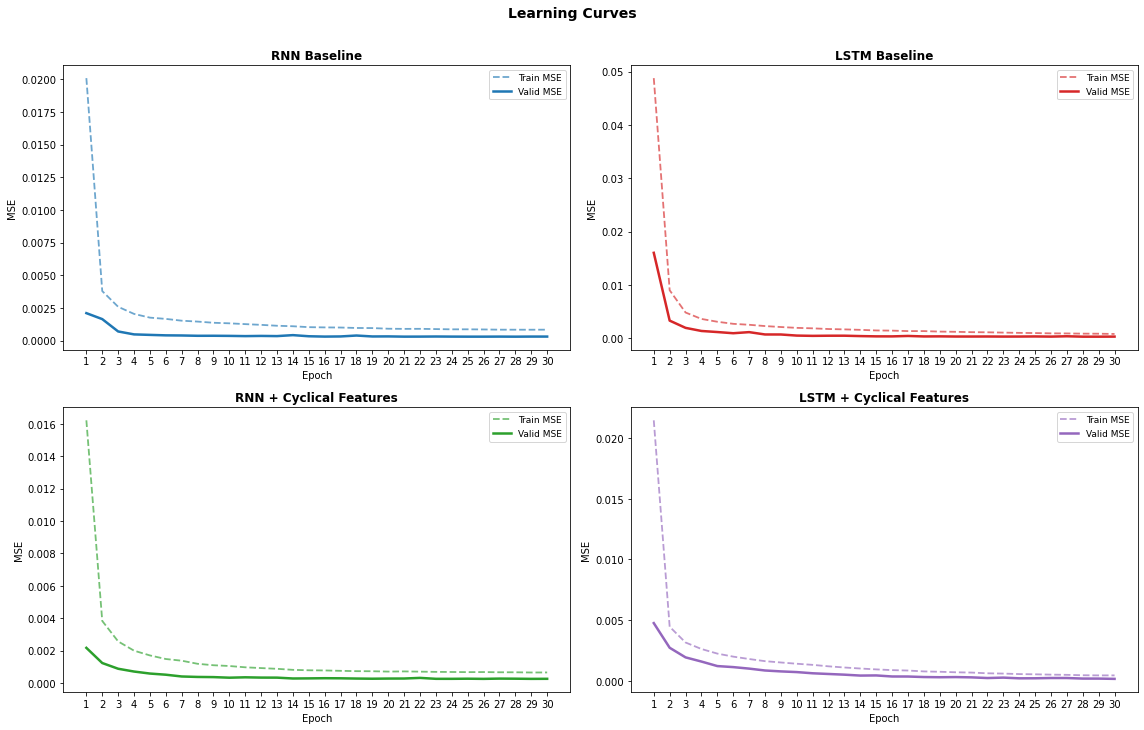

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

configs = [
    (axes[0, 0], hist_rnn_base,  'RNN Baseline', "tab:blue"),
    (axes[0, 1], hist_lstm_base, 'LSTM Baseline', "tab:red"),
    (axes[1, 0], hist_rnn_feat,  'RNN + Cyclical Features', "tab:green"),
    (axes[1, 1], hist_lstm_feat, 'LSTM + Cyclical Features', "tab:purple"),
]

for ax, hist, title, color in configs:
    ep       = range(1, len(hist['train_loss']) + 1)
    best_ep  = int(np.argmin(hist['valid_loss'])) + 1
    best_val = min(hist['valid_loss'])

    ax.plot(ep, hist['train_loss'], '--', color=color, alpha=0.65,
            linewidth=1.8, label='Train MSE')
    ax.plot(ep, hist['valid_loss'], '-',  color=color,
            linewidth=2.5, label='Valid MSE')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.legend(fontsize=9)
    ax.set_xticks(list(ep))

plt.suptitle('Learning Curves',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## Predictions vs Actuals

In [24]:
y_true, pred_rnn_base  = get_predictions(rnn_base,  test_loader_base)
y_true, pred_lstm_base = get_predictions(lstm_base, test_loader_base)
y_true, pred_rnn_feat  = get_predictions(rnn_feat,  test_loader_feat)
y_true, pred_lstm_feat = get_predictions(lstm_feat, test_loader_feat)

print(f'Test samples : {len(y_true):,}')

Test samples : 17,405


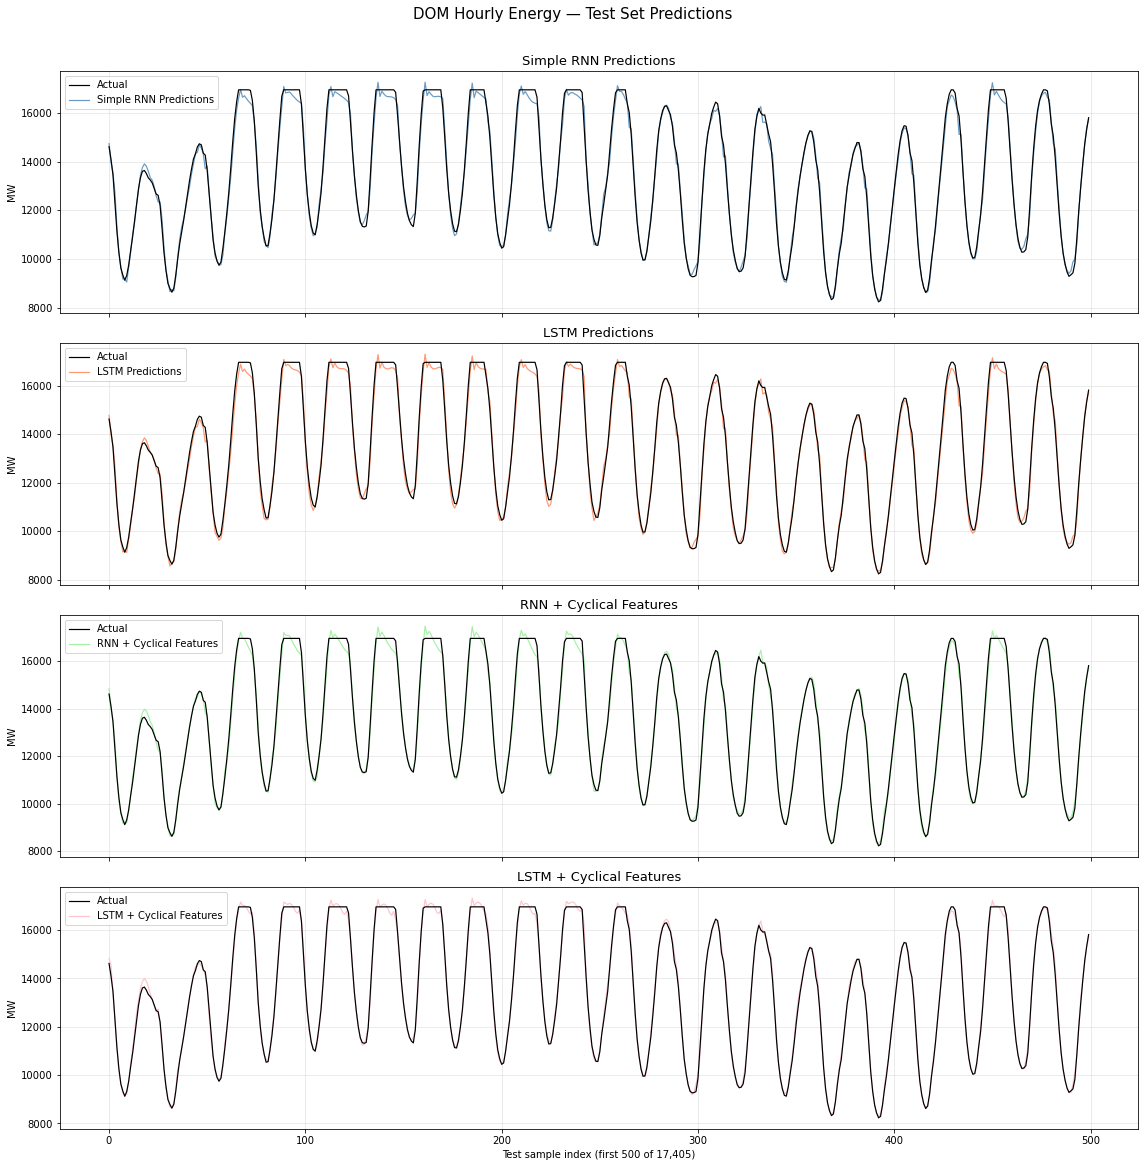

In [25]:
PLOT_WINDOW = 500   # show first N test samples for clarity

fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=True)

for ax, pred, title, color in zip(
    axes,
    [pred_rnn_base,  pred_lstm_base, pred_rnn_feat,  pred_lstm_feat],
    ["Simple RNN Predictions", "LSTM Predictions", "RNN + Cyclical Features", "LSTM + Cyclical Features"],
    ["steelblue", "coral", "lightgreen", "lightpink"],
):
    ax.plot(y_true[:PLOT_WINDOW],  color="black", linewidth=1.2,  label="Actual", zorder=3)
    ax.plot(pred[:PLOT_WINDOW], color=color, linewidth=1.2, alpha=0.8, label=title)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel("MW")
    ax.legend()
    ax.grid(alpha=0.3)

axes[-1].set_xlabel(f"Test sample index (first {PLOT_WINDOW} of {len(y_true):,})")
plt.suptitle("DOM Hourly Energy — Test Set Predictions", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("predictions.png", dpi=150, bbox_inches="tight")
plt.show()

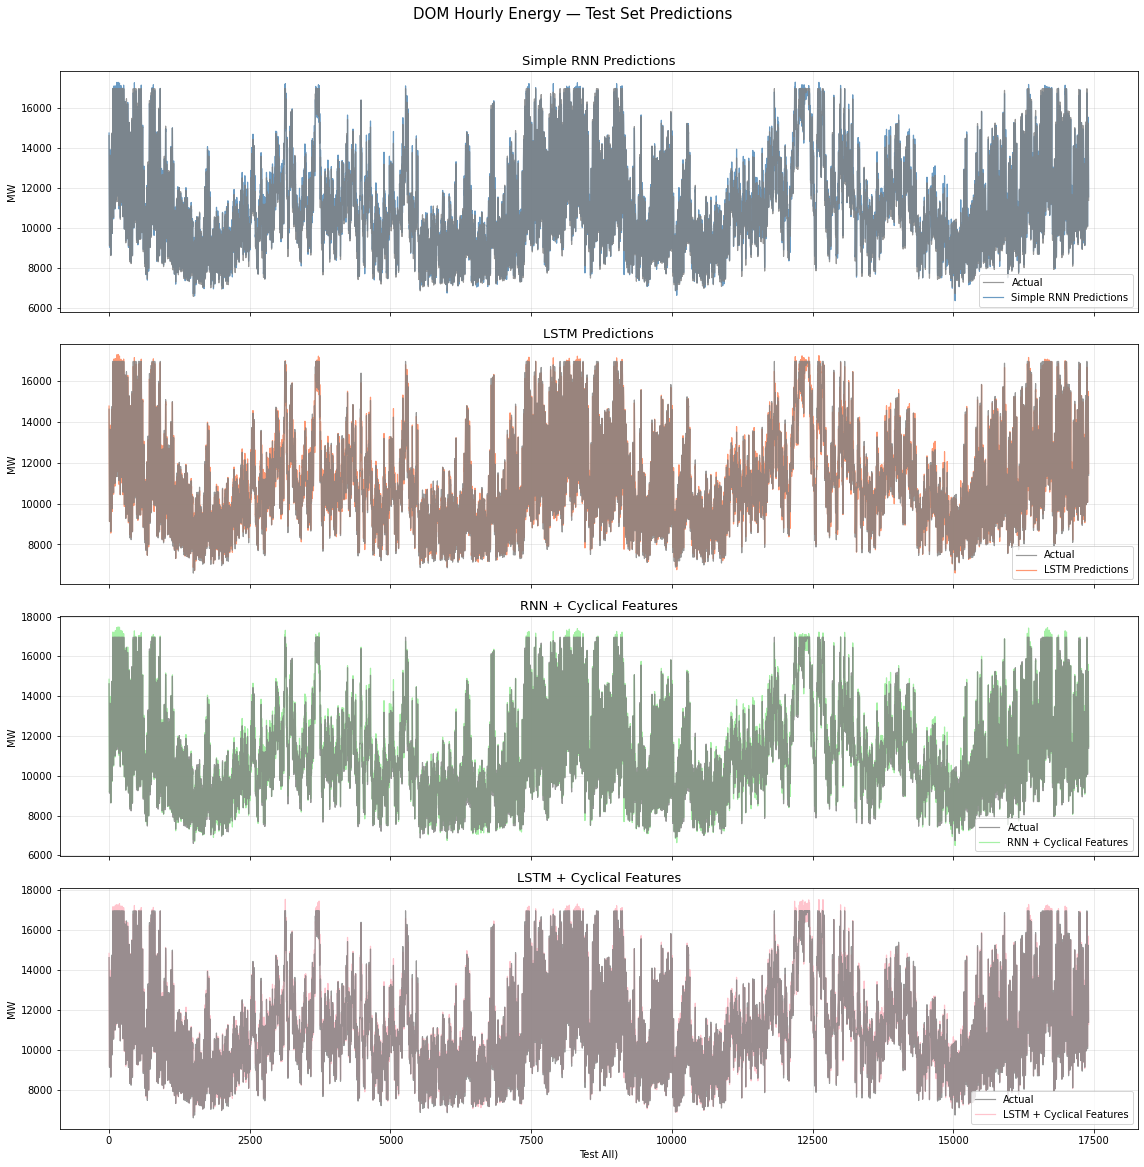

In [26]:
fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=True)

for ax, pred, title, color in zip(
    axes,
    [pred_rnn_base,  pred_lstm_base, pred_rnn_feat,  pred_lstm_feat],
    ["Simple RNN Predictions", "LSTM Predictions", "RNN + Cyclical Features", "LSTM + Cyclical Features"],
    ["steelblue", "coral", "lightgreen", "lightpink"],
):
    ax.plot(y_true[:],  color="gray", linewidth=1.2,  label="Actual", zorder=3, alpha = 0.8)
    ax.plot(pred[:], color=color, linewidth=1.2, alpha=0.8, label=title)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel("MW")
    ax.legend()
    ax.grid(alpha=0.3)

axes[-1].set_xlabel(f"Test All)")
plt.suptitle("DOM Hourly Energy — Test Set Predictions", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("predictions.png", dpi=150, bbox_inches="tight")
plt.show()

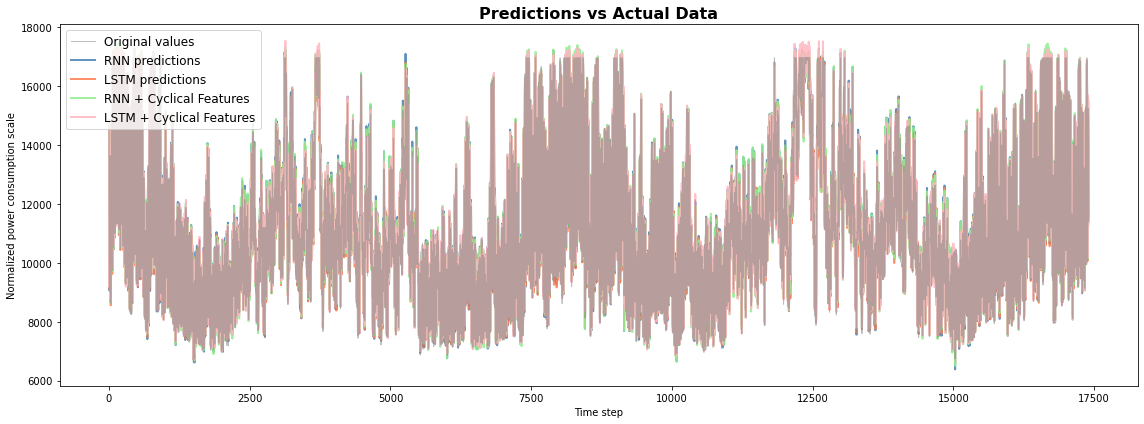

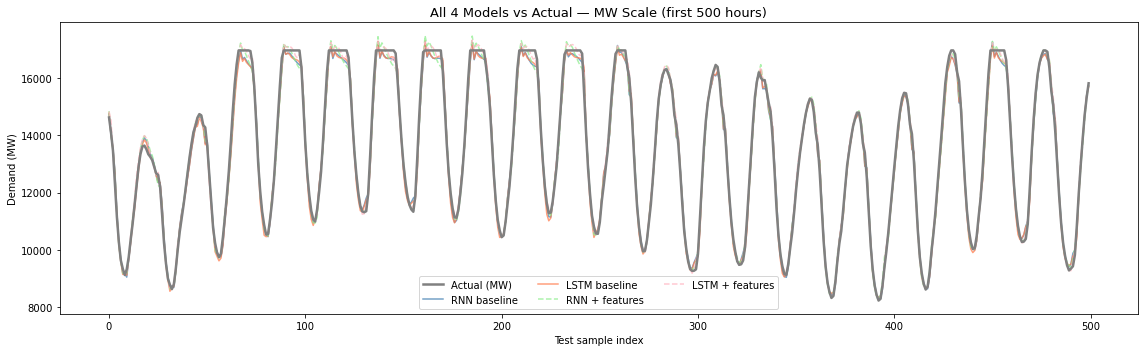

In [27]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(y_true,    color='gray',     linewidth=1,  label='Original values',  zorder=5, alpha = 0.5)
ax.plot(pred_rnn_base, color='steelblue',        linewidth=2.0,  alpha=0.85, label='RNN predictions')
ax.plot(pred_lstm_base,  color='coral',      linewidth=2.0,  alpha=0.85,  label='LSTM predictions')
ax.plot(pred_rnn_feat, color='lightgreen',        linewidth=2.0,  alpha=0.85, label='RNN + Cyclical Features')
ax.plot(pred_lstm_feat,  color='lightpink',      linewidth=2.0,  alpha=0.85,  label='LSTM + Cyclical Features')

ax.set_title('Predictions vs Actual Data', fontsize=16, fontweight='bold')
ax.set_xlabel('Time step')
ax.set_ylabel('Normalized power consumption scale')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(y_true[:PLOT_WINDOW],            color='gray', linewidth=2.5, label='Actual (MW)', zorder=5)
ax.plot(pred_rnn_base[:PLOT_WINDOW],     color='steelblue',  linewidth=1.5, alpha=0.75, label='RNN baseline')
ax.plot(pred_lstm_base[:PLOT_WINDOW],    color='coral', linewidth=1.5, alpha=0.75, label='LSTM baseline')
ax.plot(pred_rnn_feat[:PLOT_WINDOW],     color='lightgreen', linewidth=1.5, alpha=0.75, linestyle='--', label='RNN + features')
ax.plot(pred_lstm_feat[:PLOT_WINDOW],    color='lightpink', linewidth=1.5, alpha=0.75, linestyle='--', label='LSTM + features')
ax.set_title(f'All 4 Models vs Actual — MW Scale (first {PLOT_WINDOW} hours)', fontsize=13)
ax.set_xlabel('Test sample index')
ax.set_ylabel('Demand (MW)')
ax.legend(fontsize=10, ncol=3)
plt.tight_layout()
plt.show()


## Metrics Summary

In [28]:
print('── Test Set Metrics (original MW scale) ──────────────────────────────────')
print(f'  {"Model":<30}  {"RMSE (MW)":>10}  {"MAE (MW)":>10}  {"R²":>7}  {"MAPE":>8}')
print('  ' + '─' * 68)
m_rb  = compute_metrics('RNN  (baseline)',       y_true, pred_rnn_base)
m_lb  = compute_metrics('LSTM (baseline)',       y_true, pred_lstm_base)
m_rf  = compute_metrics('RNN  (+ time feats)',   y_true, pred_rnn_feat)
m_lf  = compute_metrics('LSTM (+ time feats)',   y_true, pred_lstm_feat)


── Test Set Metrics (original MW scale) ──────────────────────────────────
  Model                            RMSE (MW)    MAE (MW)       R²      MAPE
  ────────────────────────────────────────────────────────────────────
  RNN  (baseline)                 RMSE=  215.46 MW  MAE=  161.28 MW  R²=0.9917  MAPE=1.44%
  LSTM (baseline)                 RMSE=  219.30 MW  MAE=  163.02 MW  R²=0.9915  MAPE=1.44%
  RNN  (+ time feats)             RMSE=  204.17 MW  MAE=  153.17 MW  R²=0.9926  MAPE=1.37%
  LSTM (+ time feats)             RMSE=  160.86 MW  MAE=  118.90 MW  R²=0.9954  MAPE=1.07%


                        RMSE      MAE     R2   MAPE
model                                              
RNN  (baseline)      215.458  161.275  0.992  1.442
LSTM (baseline)      219.304  163.021  0.991  1.443
RNN  (+ time feats)  204.170  153.171  0.993  1.370
LSTM (+ time feats)  160.865  118.896  0.995  1.068


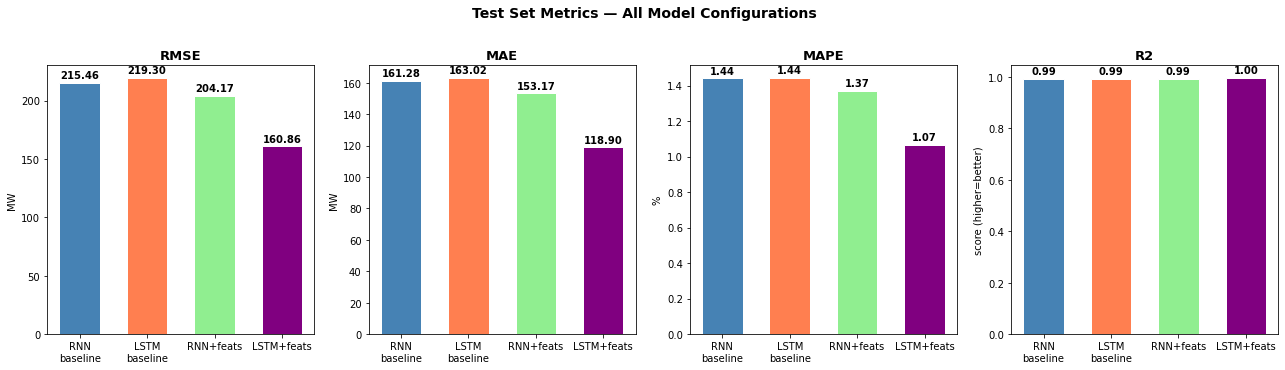

In [29]:
all_metrics = [m_rb, m_lb, m_rf, m_lf]
results_df  = pd.DataFrame(all_metrics).set_index('model').round(3)
print(results_df.to_string())

# Bar charts
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
bar_colors = ['steelblue', 'coral', 'lightgreen', 'purple']
x_labels   = ['RNN\nbaseline', 'LSTM\nbaseline', 'RNN+feats', 'LSTM+feats']

for ax, metric, ylabel in zip(axes,
                               ['RMSE', 'MAE', 'MAPE', 'R2'],
                               ['MW', 'MW', '%', 'score (higher=better)']):
    vals = [m[metric] for m in all_metrics]
    bars = ax.bar(x_labels, vals, color=bar_colors, edgecolor='white', width=0.6)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel)

plt.suptitle('Test Set Metrics — All Model Configurations', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('metrics_all.png', dpi=150, bbox_inches='tight')
plt.show()


## 14. Save Models

In [30]:
torch.save(rnn_base.state_dict(),  'rnn_baseline.pt')
torch.save(lstm_base.state_dict(), 'lstm_baseline.pt')
torch.save(rnn_feat.state_dict(),  'rnn_features.pt')
torch.save(lstm_feat.state_dict(), 'lstm_features.pt')
print('Saved: rnn_baseline.pt  lstm_baseline.pt  rnn_features.pt  lstm_features.pt')


Saved: rnn_baseline.pt  lstm_baseline.pt  rnn_features.pt  lstm_features.pt


## Key findings

- **LSTM outperforms simple RNN** across all metrics. The gated cell state allows LSTM to retain relevant information over 24+ time steps, whereas vanilla RNN struggles with vanishing gradients over long sequences.
- **Cyclical time features improve both models** — giving the model explicit knowledge of the hour, weekday, and season reduces the amount of periodic structure the recurrent state must learn implicitly.
- **Outlier cleaning helps** - data cleaning is important and can give us better results

## Rooms for improve
- **Additional features** — temperature data, public holidays, lag-24 and lag-168 of the target
- **Model tuning** — tune parameters for model